In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
early_twenties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/100simulation_results_age_20_24.csv')
late_twenties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/100simulation_results_age_25_29.csv')
early_thirties = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/processed/100simulation_results_age_30_34.csv')

In [16]:
# define wanted window
df = early_thirties

rois that stabilized for 95% CI: [32, 33, 35, 40, 65, 92, 98, 99, 100, 102, 103, 104, 105, 107, 108, 113, 114, 143, 152, 155, 169, 193, 198, 231, 233, 234, 235, 237, 239, 240, 241, 242, 243, 256, 268, 269, 270, 293, 302, 303, 304, 305, 306, 308, 309, 311, 312, 318, 323, 340, 360, 370, 391, 414, 416, 418, 421, 422, 423, 428, 441, 442, 443, 448, 449, 32, 33, 35, 37, 39, 41, 62, 97, 98, 99, 101, 102, 103, 104, 125, 143, 152, 153, 156, 166, 169, 174, 177, 217, 226, 231, 232, 233, 235, 237, 239, 241, 250, 260, 263, 270, 286, 302, 305, 306, 307, 309, 311, 320, 323, 324, 340, 360, 366, 371, 372, 373, 374, 379, 381, 401, 402, 404, 410, 412, 421, 422, 426, 429, 431, 439, 448, 449, 453, 10, 30, 31, 32, 35, 36, 39, 41, 52, 62, 65, 81, 82, 89, 97, 98, 100, 101, 102, 103, 104, 107, 108, 122, 125, 143, 152, 153, 154, 155, 156, 159, 174, 198, 200, 201, 212, 228, 229, 230, 231, 232, 237, 239, 241, 248, 250, 252, 260, 273, 274, 280, 282, 285, 288, 294, 302, 303, 308, 309, 310, 314, 320, 322, 329, 340, 

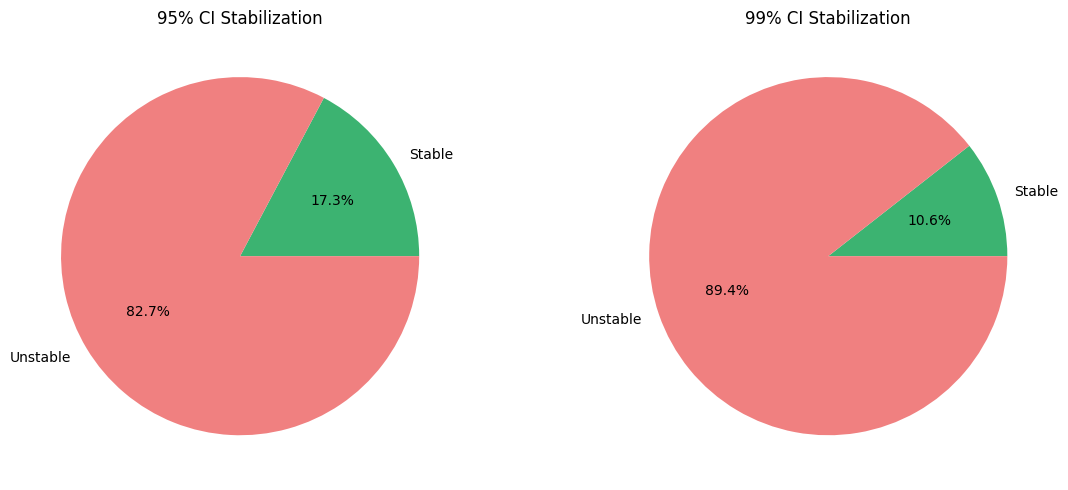

In [17]:
stable_95 = df[~df['first_sample_size_95'].isnull()]['roi'].tolist()
stable_99 = df[~df['first_sample_size_99'].isnull()]['roi'].tolist()

print(f"rois that stabilized for 95% CI: {stable_95}")
print(f"rois that stabilized for 99% CI: {stable_99}")

# pie chart of null vs non-null for 95% and 99% CI stabilization
stable_95_count = df['first_sample_size_95'].notnull().sum()
unstable_95_count = df['first_sample_size_95'].isnull().sum()
stable_99_count = df['first_sample_size_99'].notnull().sum()
unstable_99_count = df['first_sample_size_99'].isnull().sum()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pie([stable_95_count, unstable_95_count], labels=['Stable', 'Unstable'], autopct='%1.1f%%', colors=['mediumseagreen', 'lightcoral'])
plt.title('95% CI Stabilization')
plt.subplot(1, 2, 2)
plt.pie([stable_99_count, unstable_99_count], labels=['Stable', 'Unstable'], autopct='%1.1f%%', colors=['mediumseagreen', 'lightcoral'])
plt.title('99% CI Stabilization')
plt.tight_layout()
plt.show()

minimal sample size for 99% CI: 70.0
minimal sample size for 95% CI: 33.0


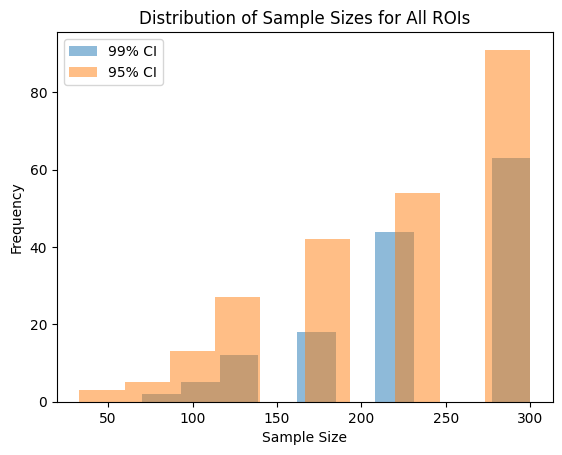

In [18]:
print(f"minimal sample size for 99% CI: {df['first_sample_size_99'].min()}")
print(f"minimal sample size for 95% CI: {df['first_sample_size_95'].min()}")

# plot a histogram of first_sample_size_99 and first_sample_size_95 for all rois
plt.hist(df['first_sample_size_99'], alpha=0.5, label='99% CI')
plt.hist(df['first_sample_size_95'], alpha=0.5, label='95% CI')
plt.xlabel('Sample Size')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Sizes for All ROIs')
plt.legend()
plt.show()